In [ ]:
import os
import detectron2
import random
import cv2
import torch
import detectron2.data.transforms as T
import numpy as np
import json

from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.data.transforms import RotationTransform

from detectron2.data import build_detection_train_loader, DatasetMapper
from detectron2.utils.visualizer import Visualizer

from detectron2.structures import BoxMode
from detectron2.data import DatasetCatalog, MetadataCatalog

# 定義數據集
def get_dicts(img_dir):
    json_file = os.path.join(img_dir, "via_project.json")
    with open(json_file) as f:
        imgs_anns = json.load(f)

    dataset_dicts = []
    for image_id, v in imgs_anns["_via_img_metadata"].items():
        record = {}
        filename = os.path.join(img_dir, v["filename"])
        height, width = cv2.imread(filename).shape[:2]
        record["file_name"] = filename
        record["image_id"] = image_id
        record["height"] = height
        record["width"] = width
        
        annos = v["regions"]  
        objs = []
        for anno in annos:
            px = anno["shape_attributes"]["all_points_x"]
            py = anno["shape_attributes"]["all_points_y"]
            poly = [(x, y) for x, y in zip(px, py)]
            poly = [p for x in poly for p in x]

            obj = {
                "bbox": [min(px), min(py), max(px), max(py)],
                "bbox_mode": BoxMode.XYXY_ABS,
                "segmentation": [poly],
                "category_id": 0,
            }
            objs.append(obj)
        record["annotations"] = objs
        dataset_dicts.append(record)
    return dataset_dicts

for d in ["train", "val"]:
    DatasetCatalog.register("pneumothorax_" + d, lambda d=d: get_dicts("/home/ubuntu/right/p_train/" + d))
    MetadataCatalog.get("pneumothorax_" + d).set(thing_classes=["pneumothorax"])

my_metadata = MetadataCatalog.get("pneumothorax_train")

# 設置配置
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("pneumothorax_train",)
cfg.DATASETS.TEST = ("pneumothorax_val",)
cfg.DATALOADER.NUM_WORKERS = 1
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 2000
cfg.SOLVER.STEPS = []
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

# 導入並呼叫 train_net.py 中的 Trainer 類
from train_net import Trainer

# 在 Trainer 中加入自定義的數據增強
class MyTrainer(Trainer):
    @classmethod
    def build_train_loader(cls, cfg):
        mapper = DatasetMapper(cfg, is_train=True, augmentations=[
            T.RandomBrightness(0.9, 1.1)  # 添加RandomBrightness增強
        ])
        return build_detection_train_loader(cfg, mapper=mapper)

# 訓練模型
trainer = MyTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()


In [2]:
import os
import copy
import detectron2

import random ,cv2 ,torch
import detectron2.data.transforms as T
import numpy as np
import json

from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.data.transforms import RotationTransform

from detectron2.data import build_detection_train_loader, DatasetMapper
from detectron2.utils.visualizer import Visualizer



ImportError: cannot import name 'MyTrainer' from 'train_net' (/home/ubuntu/right/p_train/train_net.py)

In [4]:
from detectron2.structures import BoxMode
from detectron2.data import DatasetCatalog, MetadataCatalog

def get_dicts(img_dir):
    # Define the path to the VIA annotation file
    json_file = os.path.join(img_dir, "via_project.json")
    # Read the VIA annotation file
    with open(json_file) as f:
        imgs_anns = json.load(f)

    dataset_dicts = []
    # Iterate over each image in the annotations
    for image_id, v in imgs_anns["_via_img_metadata"].items():
        record = {}
        # Get the image filename
        filename = os.path.join(img_dir, v["filename"])
        # Read the image to get its dimensions
        height, width = cv2.imread(filename).shape[:2]
        # Store image related information in the record
        record["file_name"] = filename
        record["image_id"] = image_id
        record["height"] = height
        record["width"] = width
      
        annos = v["regions"]  
        objs = []
        # Iterate over each annotation region
        for anno in annos:
            # The VIA annotation is of polygon type
            px = anno["shape_attributes"]["all_points_x"]
            py = anno["shape_attributes"]["all_points_y"]
            # Combine x and y coordinates into a list of polygon points
            poly = [(x, y) for x, y in zip(px, py)]
            poly = [p for x in poly for p in x] # Flatten the list to match Detectron2's format

            obj = {
                "bbox": [min(px), min(py), max(px), max(py)],
                "bbox_mode": BoxMode.XYXY_ABS, # Bounding box format
                "segmentation": [poly], # Points for polygon segmentation
                "category_id": 0,  # Update accordingly if there are multiple categories
            }
            objs.append(obj)
        record["annotations"] = objs
        dataset_dicts.append(record)
    return dataset_dicts
# Register the dataset and metadata
for d in ["train", "val"]:
    DatasetCatalog.register("pneumothorax_" + d, lambda d=d: get_dicts("/home/ubuntu/right/p_train/" + d))
    MetadataCatalog.get("pneumothorax_" + d).set(thing_classes=["pneumothorax"])

my_metadata = MetadataCatalog.get("pneumothorax_train")

In [5]:
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("pneumothorax_train",)
cfg.DATASETS.TEST = ("pneumothorax_val",)
cfg.DATALOADER.NUM_WORKERS = 1
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")  # Let training initialize from model zoo
cfg.SOLVER.IMS_PER_BATCH = 2  # This is the real "batch size" commonly known to deep learning people
cfg.SOLVER.BASE_LR = 0.00025  # pick a good LR , Default:0.00025
cfg.SOLVER.MAX_ITER = 2000  # 300 iterations seems good enough for this toy dataset; you will need to train longer for a practical dataset
cfg.SOLVER.STEPS = []        # do not decay learning rate
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128   # The "RoIHead batch size". 128 is faster, and good enough for this toy dataset (default: 512)
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1  # only has one class (ballon). (see https://detectron2.readthedocs.io/tutorials/datasets.html#update-the-config-for-new-datasets)
# NOTE: this config means the number of classes, but a few popular unofficial tutorials incorrect uses num_classes+1 here.

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
trainer = MyTrainer(cfg) 
trainer.resume_or_load(resume=False)
trainer.train()

NameError: name 'MyTrainer' is not defined

In [1]:
######
import os
import copy
import detectron2

import random
import cv2
import torch
import detectron2.data.transforms as T
import numpy as np
import os
import json

from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.data.transforms import RotationTransform

from detectron2.data import build_detection_train_loader, DatasetMapper
from detectron2.utils.visualizer import Visualizer

from detectron2.structures import BoxMode
from detectron2.data import DatasetCatalog, MetadataCatalog

In [3]:
# Import the train_net module
import train_net

# Use the get_cfg function to set up the configuration
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("pneumothorax_train",)
cfg.DATASETS.TEST = ("pneumothorax_val",)
cfg.DATALOADER.NUM_WORKERS = 1
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 2000
cfg.SOLVER.STEPS = []
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

# Call the main function from train_net
train_net.main(cfg)

AttributeError: config_file

In [4]:
%load_ext tensorboard
%tensorboard --logdir output

In [5]:
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")  # path to the model we just trained
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.7   # set a custom testing threshold
predictor = DefaultPredictor(cfg)

[05/30 15:56:50 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output/model_final.pth ...


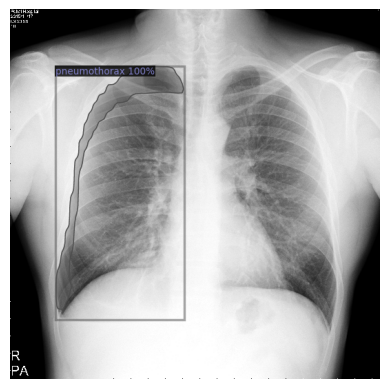

In [6]:
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import ColorMode
# Get the dataset dictionaries for the validation set
dataset_dicts = get_dicts("/home/ubuntu/right/p_train/val")
# Randomly select one sample from the dataset
for d in random.sample(dataset_dicts, 1):
    im = cv2.imread(d["file_name"])
    outputs = predictor(im)    # Perform prediction on the image using the trained model
    # Initialize the Visualizer with the image and metadata
    v = Visualizer(im[:, :, ::-1],   # Convert BGR to RGB
                   metadata=my_metadata,   # Metadata for class labels and colors
                   scale=0.2,    # Scale the visualizer output
                   instance_mode=ColorMode.IMAGE_BW   # Display the image in black and white
    )
    # Draw the predicted instances on the image
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

    # Display the image with predictions using matplotlib
    plt.imshow(out.get_image()[:, :, ::-1])
    plt.axis('off')  
    plt.show()

In [7]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader
evaluator = COCOEvaluator("pneumothorax_val", output_dir="./output")
val_loader = build_detection_test_loader(cfg, "pneumothorax_val")
print(inference_on_dataset(predictor.model, val_loader, evaluator))

[05/30 15:57:02 d2.evaluation.coco_evaluation]: Trying to convert 'pneumothorax_val' to COCO format ...
WARNING [05/30 15:57:02 d2.data.datasets.coco]: Using previously cached COCO format annotations at './output/pneumothorax_val_coco_format.json'. You need to clear the cache file if your dataset has been modified.
[05/30 15:57:04 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[05/30 15:57:04 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[05/30 15:57:04 d2.data.common]: Serializing 50 elements to byte tensors and concatenating them all ...
[05/30 15:57:04 d2.data.common]: Serialized dataset takes 0.05 MiB
[05/30 15:57:04 d2.evaluation.evaluator]: Start inference on 50 batches
[05/30 15:57:06 d2.evaluation.evaluator]: Inference done 11/50. Dataloading: 0.0045 s/iter. Inference: 0.0784 s/iter. Eval: 0.0132 s/iter. Tota

[05/30 15:58:48 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output/model_final.pth ...
{'instances': Instances(num_instances=2, image_height=4248, image_width=3480, fields=[pred_boxes: Boxes(tensor([[ 317.2200,  488.0337, 1279.3282, 3328.4131],
        [ 273.2446,  709.1741,  787.0111, 3373.0325]], device='cuda:0')), scores: tensor([0.9813, 0.9209], device='cuda:0'), pred_classes: tensor([0, 0], device='cuda:0'), pred_masks: tensor([[[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         ...,
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False]],

        [[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, 

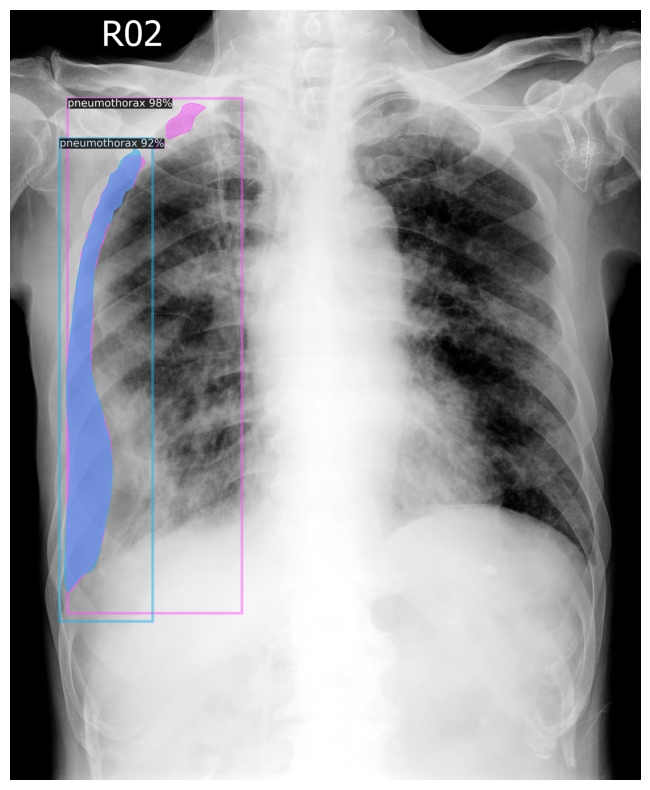

In [10]:
# Initialize the predictor with the configuration
predictor = DefaultPredictor(cfg)
# Define the path to the test image
image_path = "/home/ubuntu/right/p_train/test/cxrz_000583.png"
im = cv2.imread(image_path)
# Perform prediction on the image using the predictor
outputs = predictor(im)

print(outputs) 
# Get the metadata for the training dataset
metadata = MetadataCatalog.get(cfg.DATASETS.TRAIN[0])
# Initialize the Visualizer with the image and metadata
v = Visualizer(im[:, :, ::-1],  # Convert BGR to RGB
               metadata=metadata, # Metadata for class labels and colors
               scale=1.2) # Scale the visualizer output
# Draw the predicted instances on the image
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
# Set the figure size for displaying the image
plt.figure(figsize=(10, 10))
plt.imshow(out.get_image()[:, :, ::-1])  # Convert RGB back to BGR for displaying
plt.axis('off')  
plt.show()

In [9]:
%load_ext tensorboard
%tensorboard --logdir output

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 55282), started 0:00:14 ago. (Use '!kill 55282' to kill it.)

[05/27 13:00:53 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output/model_final.pth ...
{'instances': Instances(num_instances=1, image_height=4248, image_width=3480, fields=[pred_boxes: Boxes(tensor([[ 269.9065,  450.0136, 1429.3517, 3488.2544]], device='cuda:0')), scores: tensor([0.9939], device='cuda:0'), pred_classes: tensor([0], device='cuda:0'), pred_masks: tensor([[[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         ...,
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False]]], device='cuda:0')])}


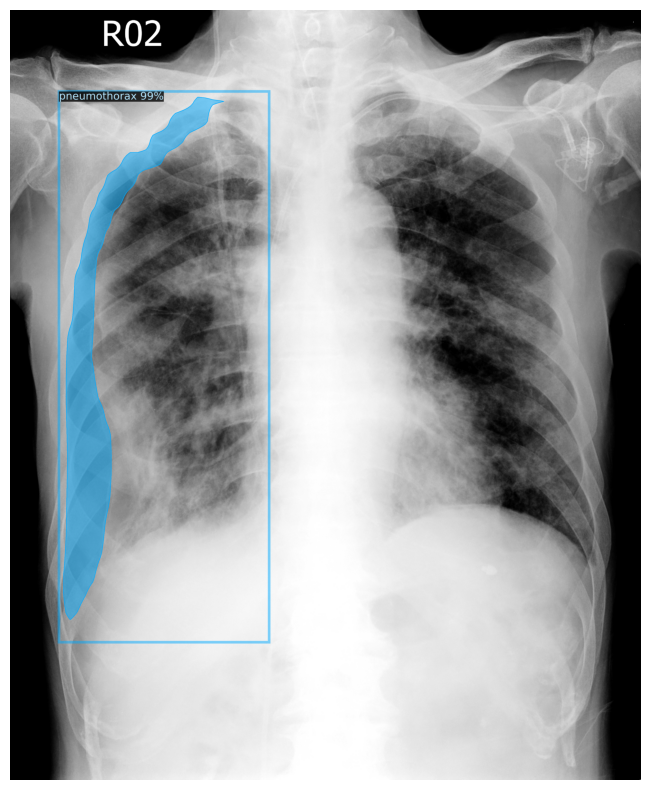

In [ ]:
predictor = DefaultPredictor(cfg)

# 讀取圖像
image_path = "/home/ubuntu/right/p_train/test/cxrz_000583.png"
im = cv2.imread(image_path)

# 執行
outputs = predictor(im)

# 預測結果
print(outputs)  

# 獲取數據
metadata = MetadataCatalog.get(cfg.DATASETS.TRAIN[0])

# 可視化結果
v = Visualizer(im[:, :, ::-1], metadata=metadata, scale=1.2)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

# 顯示圖片
plt.figure(figsize=(10, 10))
plt.imshow(out.get_image()[:, :, ::-1])
plt.axis('off')  
plt.show()